# Stage 2 — EDA: Fortuna Düsseldorf

Team: **Fortuna Düsseldorf** (`team_name` in `config.yaml`) — the largest single-team
sample available in the 7 released matches (home team in 5 of 7: J03WPY, J03WOH,
J03WQQ, J03WOY, J03WR9).

**Scope, stated up front because it isn't uniform across sections:**
- Section 1 (event type distribution) uses *every* event in Fortuna's 5 matches
  (both teams) — a dataset-overview chart, not team-specific.
- Sections 2–7 use *Fortuna's own* passes / players / positions only.
- Section 5 (pass network) aggregates across all 5 matches for more data than a
  single game gives; Stage 6 will do a single-match version for a concrete visual.

In [1]:
import sys
sys.path.insert(0, "..")  # so `src` is importable from notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import pyarrow.parquet as pq
import yaml

from src.pitch import draw_pitch
from src.parse import compute_distance_covered_km

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
with open("../config.yaml") as f:
    CONFIG = yaml.safe_load(f)
TEAM_NAME = CONFIG["team_name"]
OUT = "../" + CONFIG["paths"]["processed_data"]

matches = pd.read_csv(f"{OUT}/matches.csv")
players = pd.read_csv(f"{OUT}/players.csv")
events = pd.read_csv(f"{OUT}/events.csv", low_memory=False)
# format="ISO8601": events.csv has a mix of with/without-microseconds timestamp
# strings (some events have .000000 fractional seconds, some don't), which
# breaks pandas' single-format fast path -- ISO8601 mode handles both.
events["timestamp"] = pd.to_datetime(events["timestamp"], utc=True, format="ISO8601")

print(f"{len(matches)} matches, {len(players)} player-match rows, {len(events)} events")

7 matches, 279 player-match rows, 9961 events


## Setup: team scope, pass definition, attack-direction normalisation

Three things every section below reuses:

1. **`player_lookup`** — one row per person, not one row per player-match. A player's
   `playing_position` in `players.csv` can differ slightly match to match (squad
   rotation, or a tagging quirk); we take the most common tag rather than picking
   whichever match happens to merge in first.
2. **Pass definition** — any event whose `event_type_path` ends in `_Pass` or
   `_Cross`, matching Stage 3's definition so the EDA previews the same population
   the model will train on. `evaluation` has two spellings for a success
   (`successfullyCompleted`, and 23 rows tagged `successful`) — a real vocabulary
   inconsistency in the raw data, not a bug; both count as success.
3. **Attack-direction normalisation** — verified empirically (via `ShotAtGoal`
   locations: the scoring team's shots cluster near the opponent's goal): the team
   tagged `TeamLeft` on a half's `KickOff` event attacks towards **+x** that half,
   `TeamRight` towards **-x**, and ends swap at half-time. Any spatial aggregation
   across halves/matches (heatmaps, pass network) without correcting for this
   blends a team's defensive third into its attacking third — so we flip
   `(x, y) -> (-x, -y)` for every event where Fortuna was `TeamRight` that half,
   giving `x_norm`/`y_norm` where Fortuna always attacks +x.

In [3]:
def most_common(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else None

player_lookup = players.groupby("person_id").agg(
    name=("name", "first"), playing_position=("playing_position", most_common)
).reset_index()

team_id = players.loc[players["team_name"] == TEAM_NAME, "team_id"].iloc[0]
team_matches = matches.loc[
    (matches["home_team_name"] == TEAM_NAME) | (matches["away_team_name"] == TEAM_NAME), "match_id"
].tolist()
print(f"{TEAM_NAME}: team_id={team_id}, {len(team_matches)} matches -> {team_matches}")

is_pass = events["event_type_path"].str.endswith(("_Pass", "_Cross"))
scope_events = events[events["match_id"].isin(team_matches)]  # both teams, for Section 1

# One non-null KickOff row per (match, half) carries the TeamLeft/TeamRight
# needed for attack-direction normalisation (retake kickoffs after a goal
# repeat the same values with a null GameSection, so filtering on notna()
# here is enough to get exactly one row per half).
kickoffs = events.loc[events["kickoff_gamesection"].notna(),
                       ["match_id", "kickoff_gamesection", "kickoff_teamleft", "timestamp"]]
kickoffs = kickoffs.rename(columns={"kickoff_gamesection": "half", "kickoff_teamleft": "team_left"})
second_half_cutoff = kickoffs.loc[kickoffs["half"] == "secondHalf"].set_index("match_id")["timestamp"]

def add_attack_normalised_columns(df, team_col="team_id"):
    """Adds half/team_left/attacks_plus_x/x_norm/y_norm. See markdown above."""
    df = df.copy()
    df["half"] = np.where(df["timestamp"] < df["match_id"].map(second_half_cutoff), "firstHalf", "secondHalf")
    team_left_by_match_half = kickoffs.set_index(["match_id", "half"])["team_left"].to_dict()
    df["team_left"] = df.set_index(["match_id", "half"]).index.map(team_left_by_match_half)
    df["attacks_plus_x"] = df[team_col] == df["team_left"]
    flip = np.where(df["attacks_plus_x"], 1, -1)
    df["x_norm"] = df["x_centred"] * flip
    df["y_norm"] = df["y_centred"] * flip
    return df

fpass = scope_events[is_pass.reindex(scope_events.index) & (scope_events["team_id"] == team_id)].copy()
fpass["is_success"] = fpass["evaluation"].isin(["successfullyCompleted", "successful"])
fpass = add_attack_normalised_columns(fpass)

# Real invariant to check: every pass resolved to a known half/team_left (no
# join misses), and the flip actually gets exercised in both directions --
# NOT that attacks_plus_x is always True, which would mean Fortuna was
# always TeamLeft, true for roughly half the halves at random, not a rule.
assert fpass["team_left"].notna().all(), "some passes didn't match a (match, half) kickoff -- join bug"
assert fpass["attacks_plus_x"].nunique() == 2, "expected both TeamLeft and TeamRight halves in this sample"
print(f"{len(fpass)} Fortuna passes/crosses, {fpass['is_success'].mean():.1%} completed")
print(fpass.groupby(["match_id", "half"])["attacks_plus_x"].first())

Fortuna Düsseldorf: team_id=DFL-CLU-00000P, 5 matches -> ['J03WPY', 'J03WOH', 'J03WQQ', 'J03WOY', 'J03WR9']
2378 Fortuna passes/crosses, 81.2% completed
match_id  half      
J03WOH    firstHalf     False
          secondHalf     True
J03WOY    firstHalf     False
          secondHalf     True
J03WPY    firstHalf     False
          secondHalf     True
J03WQQ    firstHalf     False
          secondHalf     True
J03WR9    firstHalf      True
          secondHalf    False
Name: attacks_plus_x, dtype: bool


## 1. Event type distribution

Every event across Fortuna's 5 matches (both teams), log-scaled x-axis — mirrors Fig. 3
of the paper.

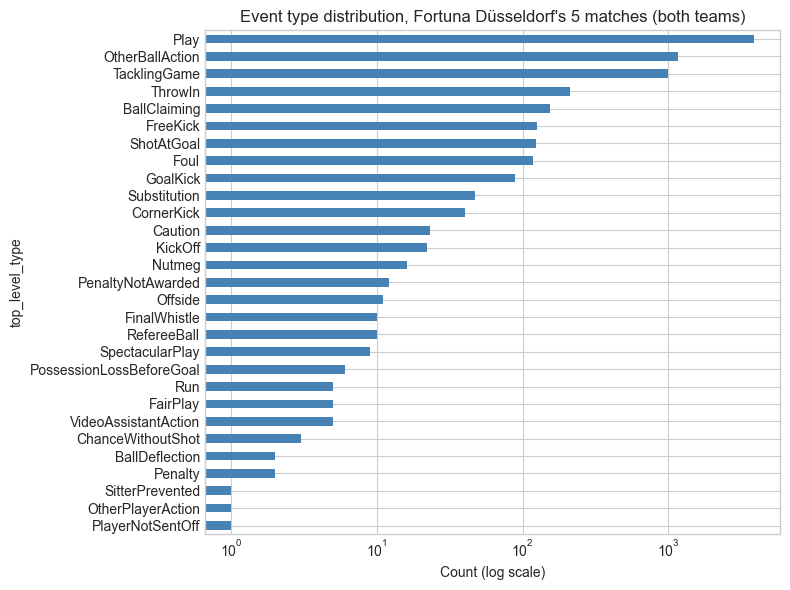

In [4]:
counts = scope_events["top_level_type"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Count (log scale)")
ax.set_title(f"Event type distribution, {TEAM_NAME}'s 5 matches (both teams)")
fig.tight_layout()
plt.show()

**Takeaway:** `Play` (mostly passes) dominates by more than 3x over the next most common
type (`OtherBallAction`), and the long tail of rare event types (single-digit counts for
`Penalty`, `OtherPlayerAction`, ...) is exactly why a log x-axis is necessary — on a linear
scale everything past the top 5 types would be invisible.

## 2. Pass counts & success rate, per player and per position

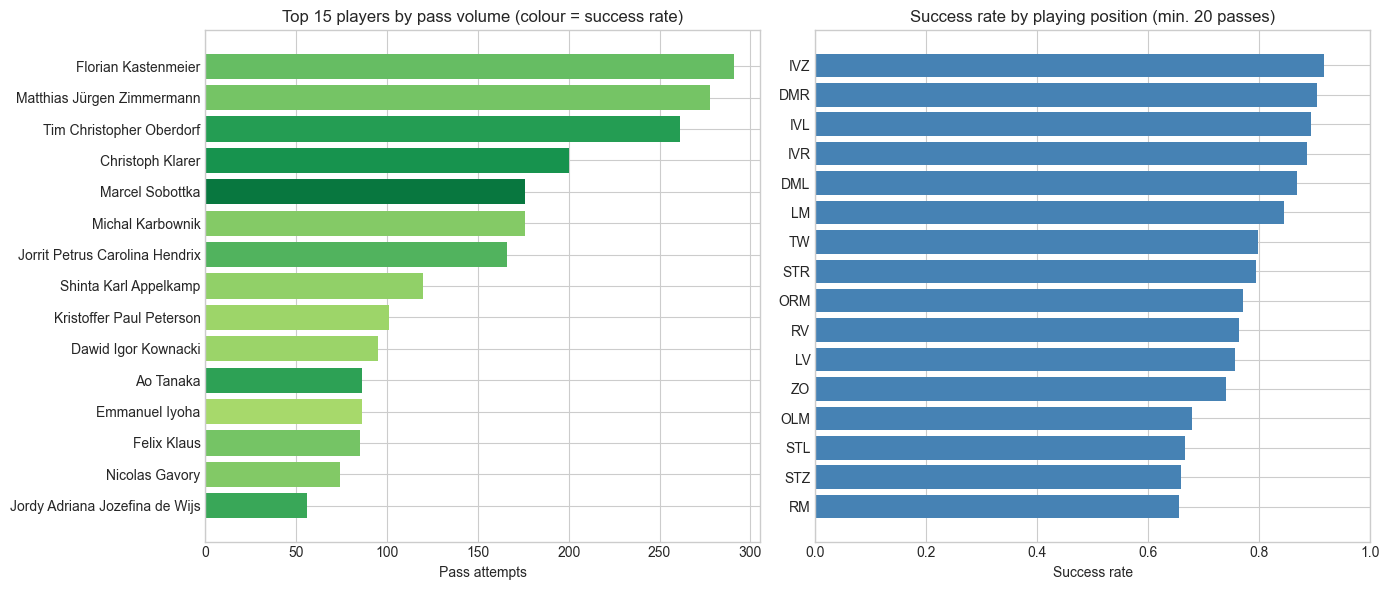

In [5]:
per_player = fpass.groupby("player_id").agg(n_passes=("event_id", "count"), success_rate=("is_success", "mean"))
per_player = per_player.merge(player_lookup, left_index=True, right_on="person_id").set_index("name")
per_player = per_player.sort_values("n_passes", ascending=False).head(15)

# Position needs its own player-match merge (not player_lookup's per-person
# mode) since we want the position actually played in that specific pass's
# match, for the handful of players used in more than one role.
pos_merge = fpass.merge(players[["person_id", "match_id", "playing_position"]],
                         left_on=["player_id", "match_id"], right_on=["person_id", "match_id"], how="left")
per_position = pos_merge.groupby("playing_position")["is_success"].agg(n_passes="count", success_rate="mean")
per_position = per_position[per_position["n_passes"] >= 20].sort_values("success_rate")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.RdYlGn(per_player["success_rate"])
axes[0].barh(per_player.index[::-1], per_player["n_passes"][::-1], color=colors[::-1])
axes[0].set_xlabel("Pass attempts")
axes[0].set_title("Top 15 players by pass volume (colour = success rate)")

axes[1].barh(per_position.index, per_position["success_rate"], color="steelblue")
axes[1].set_xlabel("Success rate")
axes[1].set_xlim(0, 1)
axes[1].set_title("Success rate by playing position (min. 20 passes)")
fig.tight_layout()
plt.show()

**Takeaway:** central/deep positions (DMR, IVL, IVR, DML) complete 87-90% of passes vs.
65-77% for wide and forward positions (RV, LV, STZ, STL) — the deep players are making
safer, shorter circulation passes while wide/attacking players attempt riskier forward
and crossing passes into contested space.

## 3. Pass distance & angle distributions; length vs. success

DFL doesn't tag a pass's end coordinate on the event itself — only the origin, a
**categorical** `Distance` bucket (`short`/`medium`/`long`), and a continuous `PlayAngle`
(degrees). A true continuous pass length needs the receiving player's tracked position,
which means synchronising to the position data — that's Stage 3. Here we use the two
fields DFL does provide directly.

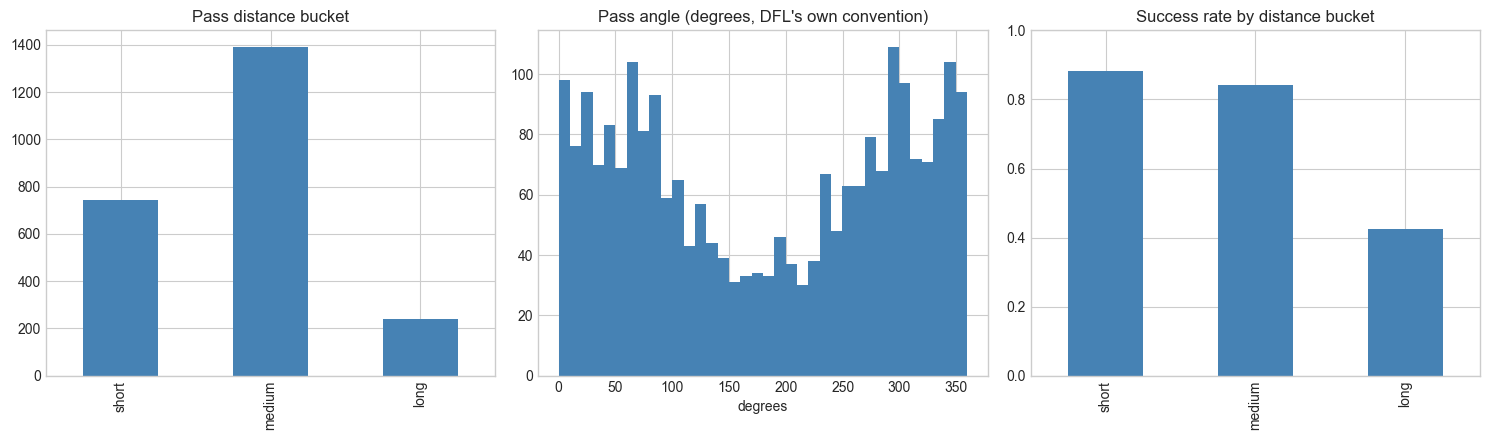

                  n  success_rate
play_distance                    
short           745      0.883221
medium         1391      0.841121
long            242      0.425620


In [6]:
dist_order = ["short", "medium", "long"]
dist_success = fpass.groupby("play_distance")["is_success"].agg(n="count", success_rate="mean").reindex(dist_order)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fpass["play_distance"].value_counts().reindex(dist_order).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Pass distance bucket")
axes[0].set_xlabel("")

fpass["play_playangle"].dropna().hist(bins=36, ax=axes[1], color="steelblue")
axes[1].set_title("Pass angle (degrees, DFL's own convention)")
axes[1].set_xlabel("degrees")

dist_success["success_rate"].plot(kind="bar", ax=axes[2], color="steelblue")
axes[2].set_title("Success rate by distance bucket")
axes[2].set_ylim(0, 1)
axes[2].set_xlabel("")
fig.tight_layout()
plt.show()
print(dist_success)

**Takeaway:** success rate drops sharply with distance (short 88% -> medium 84% -> long
43%) — a clean, expected monotonic relationship that's a good sanity check on the
`Distance`/`Evaluation` fields themselves, and a strong hint that `dist_to_passer` alone
will be a solid Stage 4 baseline feature.

## 4. Pass origin / destination heatmaps

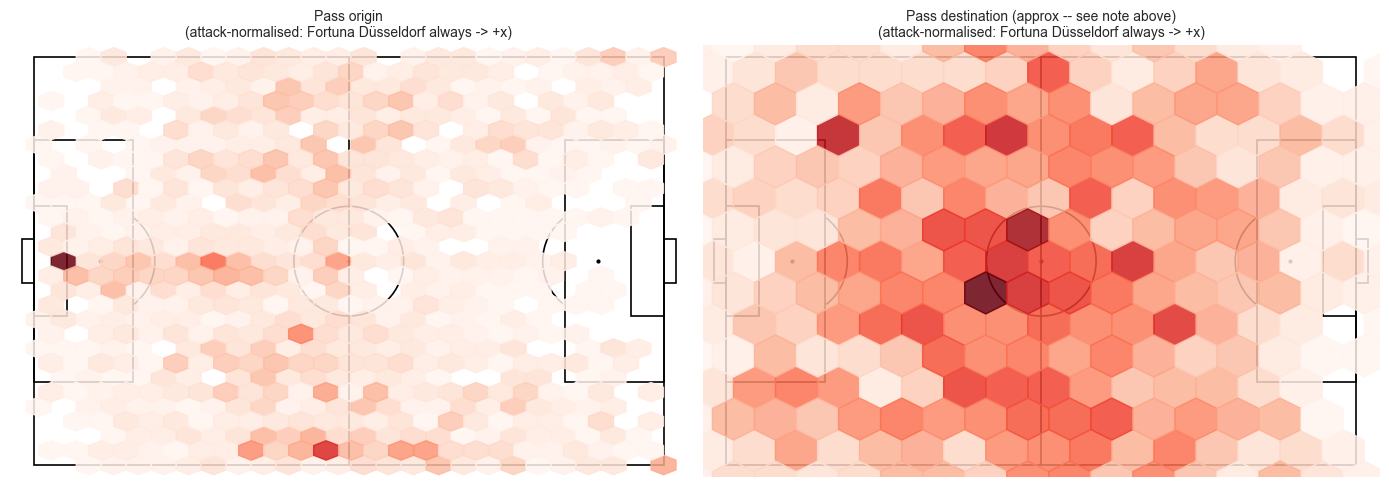

In [7]:
# Approximate destination = origin + (distance-bucket midpoint) at PlayAngle,
# in RAW (pre-normalisation) space, since PlayAngle was tagged in that frame
# -- then apply the same flip used for x_norm/y_norm. This is a rough EDA-only
# proxy (bucket midpoints are a guess), never used downstream in Stage 3,
# where destinations come from actual synchronised tracking positions instead.
DIST_BUCKET_MIDPOINT_M = {"short": 10, "medium": 25, "long": 40}
bucket_m = fpass["play_distance"].map(DIST_BUCKET_MIDPOINT_M)
angle_rad = np.deg2rad(fpass["play_playangle"])
flip = np.where(fpass["attacks_plus_x"], 1, -1)
dest_x_norm = (fpass["x_centred"] + bucket_m * np.cos(angle_rad)) * flip
dest_y_norm = (fpass["y_centred"] + bucket_m * np.sin(angle_rad)) * flip

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, x, y, title in [
    (axes[0], fpass["x_norm"], fpass["y_norm"], "Pass origin"),
    (axes[1], dest_x_norm, dest_y_norm, "Pass destination (approx -- see note above)"),
]:
    draw_pitch(ax)
    valid = x.notna() & y.notna()
    ax.hexbin(x[valid], y[valid], gridsize=25, cmap="Reds", mincnt=1, alpha=0.85)
    ax.set_title(f"{title}\n(attack-normalised: {TEAM_NAME} always -> +x)", fontsize=10)
fig.tight_layout()
plt.show()

**Takeaway:** origin is heaviest in the defensive third (build-up from the keeper and
centre-backs), destination shifts clearly into the middle third just past the halfway
line — consistent with a team that circulates possession deep before progressing, rather
than playing direct long balls forward (matches the 84% medium / 43% long split above).

## 5. Pass network

Nodes at each player's mean pass-origin position (attack-normalised), edge width by pass
count. Built from **completed** passes only — a pass network is meant to show actual ball
circulation structure, which is a different question from Stage 3's "who was this aimed
at" (which deliberately keeps failed passes, using `recipient_id` as intent).

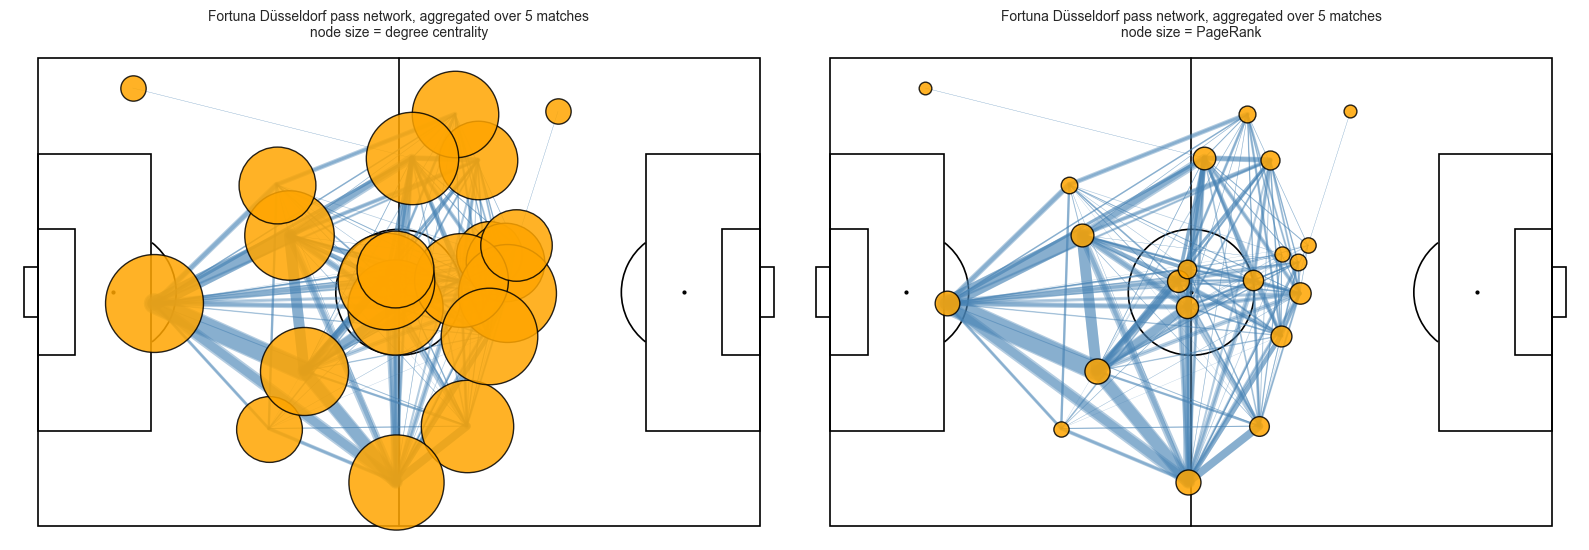

Tim Christopher Oberdorf: pagerank=0.089
Matthias Jürgen Zimmermann: pagerank=0.088
Florian Kastenmeier: pagerank=0.085


In [8]:
completed = fpass[fpass["is_success"] & fpass["recipient_id"].notna()]
completed = completed[completed["recipient_id"].isin(player_lookup["person_id"])]

edge_counts = completed.groupby(["player_id", "recipient_id"]).size().reset_index(name="n")
node_pos = completed.groupby("player_id")[["x_norm", "y_norm"]].mean()

G = nx.DiGraph()
G.add_nodes_from(set(edge_counts["player_id"]) | set(edge_counts["recipient_id"]))
for _, row in edge_counts.iterrows():
    G.add_edge(row["player_id"], row["recipient_id"], weight=row["n"])

degree_cent = nx.degree_centrality(G)
pagerank = nx.pagerank(G, weight="weight")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, metric, title in [(axes[0], degree_cent, "node size = degree centrality"),
                           (axes[1], pagerank, "node size = PageRank")]:
    draw_pitch(ax)
    for _, row in edge_counts.iterrows():
        if row["player_id"] not in node_pos.index or row["recipient_id"] not in node_pos.index:
            continue
        x1, y1 = node_pos.loc[row["player_id"]]
        x2, y2 = node_pos.loc[row["recipient_id"]]
        ax.plot([x1, x2], [y1, y2], color="steelblue", alpha=0.4, linewidth=row["n"] / 4, zorder=2)
    for pid in node_pos.index:
        x, y = node_pos.loc[pid]
        ax.scatter(x, y, s=metric.get(pid, 0) * 3000 + 60, color="orange", edgecolor="black", zorder=3, alpha=0.85)
    ax.set_title(f"{TEAM_NAME} pass network, aggregated over 5 matches\n{title}", fontsize=10)
fig.tight_layout()
plt.show()

top_pagerank = sorted(pagerank.items(), key=lambda kv: -kv[1])[:3]
for pid, score in top_pagerank:
    name = player_lookup.set_index("person_id").loc[pid, "name"]
    print(f"{name}: pagerank={score:.3f}")

**Takeaway:** the top 3 by PageRank are the right centre-back, the right-back, and the
keeper — not the highest-volume passers by raw count, but the players who receive the
ball first out of defensive build-up and are structurally central to how possession
starts, which is exactly the distinction PageRank is meant to surface over a raw degree
count.

## 6. Minutes played & distance covered, from position data

Minutes played = span of each player's own tracked frames (their FrameSet starts at
kickoff or their substitution-on moment, and stops at full time, substitution-off, or a
red card — confirmed in Stage 1) rather than cross-referencing `Substitution` events
separately. Distance uses `compute_distance_covered_km`, a **full-resolution** re-stream
of the raw 25Hz file (not the downsampled parquet) — Stage 1 established that summing `D`
over the downsampled 8.33Hz rows undercounts distance by roughly 3x, since most of the
path length lives in the frames we drop. This cell takes ~30-40s for that reason.

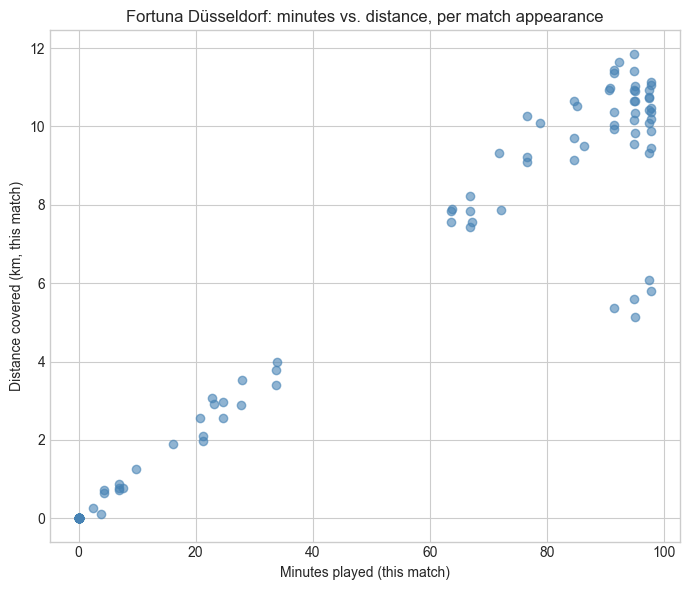

,name,playing_position,n_matches,total_minutes,total_km,km_per_90
person_id,,,,,,
DFL-OBJ-0000NZ,Matthias Jürgen Zimmermann,RV,5,476.730,51.484427,9.719544
DFL-OBJ-0028FW,Florian Kastenmeier,TW,5,476.730,27.972939,5.280902
DFL-OBJ-002FXT,Dawid Igor Kownacki,STZ,5,419.304,45.575191,9.782323
DFL-OBJ-002GM9,Christoph Klarer,IVL,5,409.906,40.732996,8.943440
DFL-OBJ-002GMO,Tim Christopher Oberdorf,IVR,5,385.256,41.938985,9.797404
DFL-OBJ-J01KJ5,Michal Karbownik,LV,5,385.256,43.873938,10.249430
DFL-OBJ-00028V,Marcel Sobottka,DMR,4,381.836,44.052380,10.383291
DFL-OBJ-002GM1,Kristoffer Paul Peterson,OLM,5,316.374,38.246551,10.880128
DFL-OBJ-J0130T,Jorrit Petrus Carolina Hendrix,DML,4,307.386,37.345264,10.934375


In [9]:
rows = []
for match_id in team_matches:
    tbl = pq.read_table(f"{OUT}/positions/{match_id}.parquet").to_pandas()
    tbl["timestamp"] = pd.to_datetime(tbl["timestamp"], utc=True, format="ISO8601")
    fortuna_ids = set(players.loc[(players["match_id"] == match_id) & (players["team_id"] == team_id), "person_id"])
    tbl = tbl[tbl["person_id"].isin(fortuna_ids)]

    minutes_per_half = tbl.groupby(["person_id", "game_section"])["timestamp"].agg(
        lambda s: (s.max() - s.min()).total_seconds() / 60)
    minutes_total = minutes_per_half.groupby("person_id").sum()

    dist_km = compute_distance_covered_km(match_id)
    for pid in fortuna_ids:
        rows.append({"match_id": match_id, "person_id": pid,
                      "minutes": minutes_total.get(pid, 0.0), "distance_km": dist_km.get(pid, 0.0)})

perf = pd.DataFrame(rows).merge(player_lookup, on="person_id", how="left")
summary = perf.groupby("person_id").agg(
    name=("name", "first"), playing_position=("playing_position", "first"),
    n_matches=("match_id", "nunique"), total_minutes=("minutes", "sum"), total_km=("distance_km", "sum"),
).sort_values("total_minutes", ascending=False)
summary["km_per_90"] = summary["total_km"] / (summary["total_minutes"] / 90)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(perf["minutes"], perf["distance_km"], alpha=0.6, color="steelblue")
ax.set_xlabel("Minutes played (this match)")
ax.set_ylabel("Distance covered (km, this match)")
ax.set_title(f"{TEAM_NAME}: minutes vs. distance, per match appearance")
fig.tight_layout()
plt.show()

summary.head(10)[["name", "playing_position", "n_matches", "total_minutes", "total_km", "km_per_90"]]

**Takeaway:** the minutes-vs-distance relationship is almost perfectly linear (as
expected) with one clearly separate lower cluster around ~5-6km at full minutes — the
goalkeeper (Kastenmeier, `km_per_90` ≈ 5.3 vs. 9-11.5 for every outfield starter), a clean
visual confirmation that the position/distance data lines up with real positional roles.

## 7. Synchronisation audit

For every Fortuna pass: distance between the event's tagged (centred) coordinates and the
ball's tracked position at the nearest-timestamp frame. This is the same measurement the
paper reports a 9.37m unsynced mean for — reproducing it here on our own pipeline is a
strong end-to-end check that parsing, centring, and timestamp handling are all correct,
and it's the number Stage 3's synchronisation step will try to improve on.

count    2378.000000
mean        8.597034
std         7.536067
min         0.080623
25%         3.370756
50%         6.640260
75%        11.408900
max        54.986286
dtype: float64


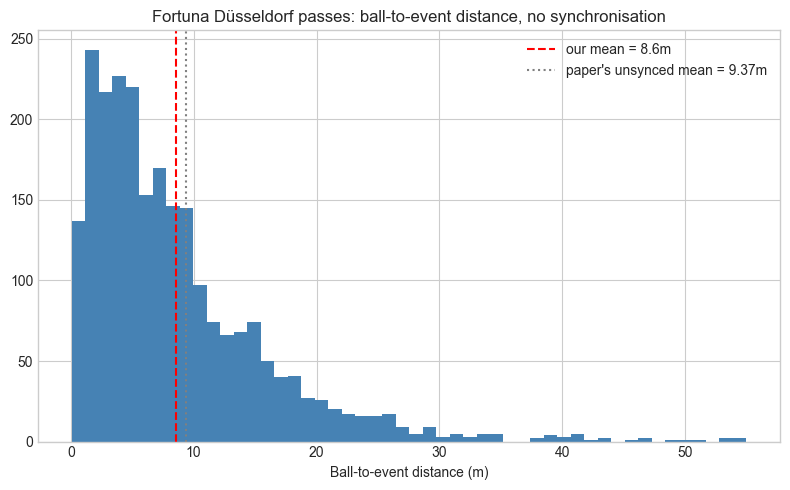

In [10]:
ball_to_event_dists = []
for match_id in team_matches:
    ball = pq.read_table(f"{OUT}/positions/{match_id}.parquet", filters=[("team_id", "=", "BALL")]).to_pandas()
    ball["timestamp"] = pd.to_datetime(ball["timestamp"], utc=True, format="ISO8601")
    ball = ball.sort_values("timestamp")

    sub = fpass.loc[fpass["match_id"] == match_id, ["timestamp", "x_centred", "y_centred"]].dropna()
    sub = sub.sort_values("timestamp")
    # merge_asof: for each pass, the nearest-timestamp ball frame -- both
    # sides must be sorted by the join key, which is why we sort just above.
    merged = pd.merge_asof(sub, ball[["timestamp", "x", "y"]], on="timestamp", direction="nearest")
    d = np.sqrt((merged["x"] - merged["x_centred"]) ** 2 + (merged["y"] - merged["y_centred"]) ** 2)
    ball_to_event_dists.append(d)

all_d = pd.concat(ball_to_event_dists)
print(all_d.describe())

fig, ax = plt.subplots(figsize=(8, 5))
all_d.hist(bins=50, ax=ax, color="steelblue")
ax.axvline(all_d.mean(), color="red", linestyle="--", label=f"our mean = {all_d.mean():.1f}m")
ax.axvline(9.37, color="grey", linestyle=":", label="paper's unsynced mean = 9.37m")
ax.legend()
ax.set_xlabel("Ball-to-event distance (m)")
ax.set_title(f"{TEAM_NAME} passes: ball-to-event distance, no synchronisation")
fig.tight_layout()
plt.show()

**Takeaway:** mean 8.6m / median 6.6m, right in line with the paper's own reported 9.37m
unsynced mean — a strong validation that the parsing pipeline is correct, and the exact
problem Stage 3's `nearest` vs. `refined` synchronisation methods are built to reduce.